# Exercício 1 - k-NN manual e sklearn

In [1]:

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter

# Dados de treino
train_data = np.array([
    [4, 7],
    [5, 6],
    [3, 4],
    [6, 9],
    [6, 4],
    [7, 6],
    [8, 0],
    [10,10],
    [12,3]
])
train_labels = np.array([0,0,0,0,1,1,1,1,1])

# Ponto de validação
val_point = np.array([6,5])

# Calcular distâncias Euclidianas
distances = np.sqrt(np.sum((train_data - val_point)**2, axis=1))
print("Distâncias:", distances)

# Obter os k vizinhos mais próximos
k3_idx = distances.argsort()[:3]
k5_idx = distances.argsort()[:5]

print("Classes k=3:", train_labels[k3_idx])
print("Classes k=5:", train_labels[k5_idx])

# Decidir pela classe mais frequente
print("Classe predita k=3:", Counter(train_labels[k3_idx]).most_common(1)[0][0])
print("Classe predita k=5:", Counter(train_labels[k5_idx]).most_common(1)[0][0])

# Conferindo com scikit-learn
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(train_data, train_labels)
print("Predito pelo sklearn (k=3):", knn3.predict([val_point]))

knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(train_data, train_labels)
print("Predito pelo sklearn (k=5):", knn5.predict([val_point]))


Distâncias: [2.82842712 1.41421356 3.16227766 4.         1.         1.41421356
 5.38516481 6.40312424 6.32455532]
Classes k=3: [1 0 1]
Classes k=5: [1 0 1 0 0]
Classe predita k=3: 1
Classe predita k=5: 0
Predito pelo sklearn (k=3): [1]
Predito pelo sklearn (k=5): [0]


# Exercício 2 - Classificação de Dígitos com k-NN

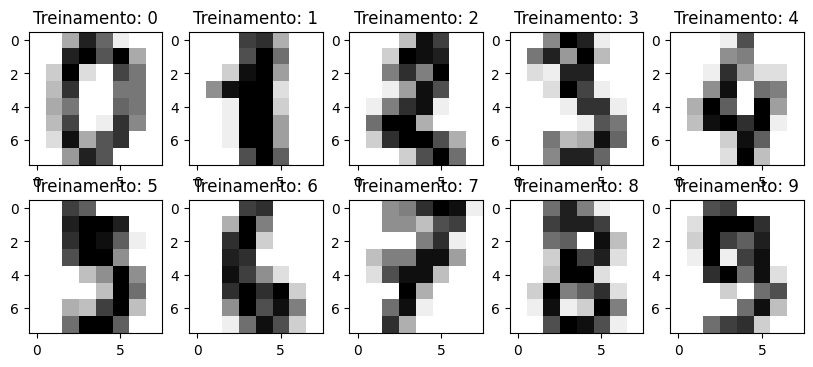

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Melhores parâmetros: {'n_neighbors': 3, 'weights': 'distance'}
Melhor score: 0.9867789392179637
Acurácia: 0.9833


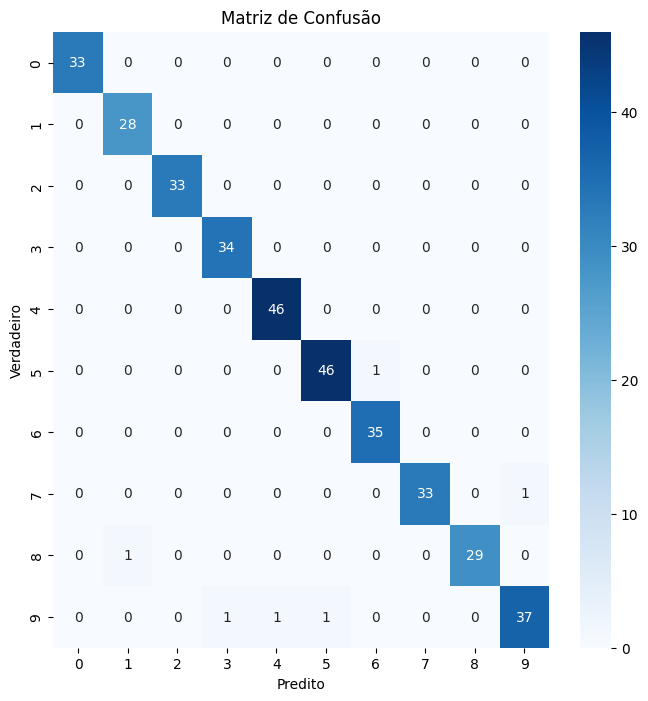

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.97      0.98        30
           9       0.97      0.93      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [2]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# Carregar dados
digits = load_digits()

# Visualizar alguns dígitos
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Treinamento: {digits.target[i]}')
plt.show()

# Transformar imagens em vetores
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# Dividir treino/teste
x_train, x_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.2, random_state=42)

# Grid Search
param_grid = {
    'n_neighbors': [1, 2, 3, 4, 5, 10, 15, 20],
    'weights': ['uniform', 'distance']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, verbose=2, n_jobs=-1)
grid.fit(x_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor score:", grid.best_score_)

# Avaliação
y_pred = grid.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f'Acurácia: {acc:.4f}')

# Matriz de confusão
mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,8))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

# Relatório
print(classification_report(y_test, y_pred))


# Exercício 3 - Comparação GaussianNB, Logistic Regression e k-NN

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Melhores parâmetros k-NN: {'n_neighbors': 15, 'weights': 'uniform'}


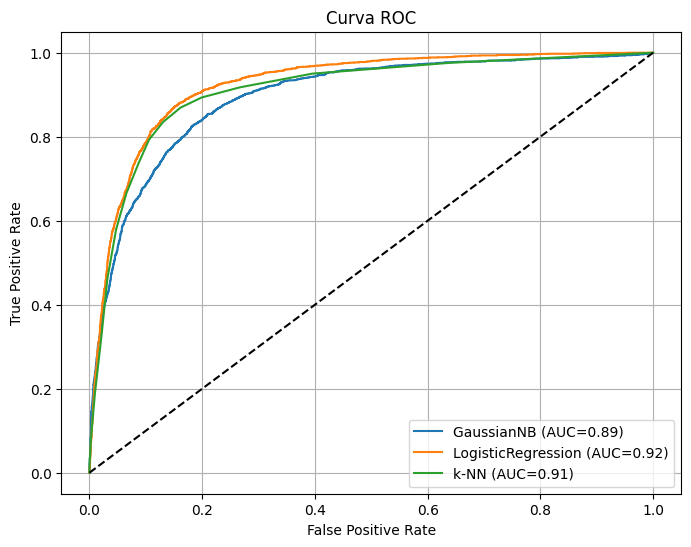

In [3]:

from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# Dados
x, y = make_classification(n_samples=10000, n_classes=2, weights=[0.9, 0.5], random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, random_state=42)

# GaussianNB
gnb = GaussianNB()
gnb.fit(x_train, y_train)
y_score_gnb = gnb.predict_proba(x_test)[:,1]

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_score_lr = lr.predict_proba(x_test)[:,1]

# k-NN com Grid Search
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, verbose=2, n_jobs=-1)
grid.fit(x_train, y_train)
print("Melhores parâmetros k-NN:", grid.best_params_)
y_score_knn = grid.predict_proba(x_test)[:,1]

# Curvas ROC
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_score_gnb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)

roc_auc_gnb = auc(fpr_gnb, tpr_gnb)
roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8,6))
plt.plot(fpr_gnb, tpr_gnb, label=f'GaussianNB (AUC={roc_auc_gnb:.2f})')
plt.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC={roc_auc_lr:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC={roc_auc_knn:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()


# Exercício 4 - k-NN Regressor

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Melhores parâmetros: {'n_neighbors': 20, 'weights': 'uniform'}
MSE: 0.0088


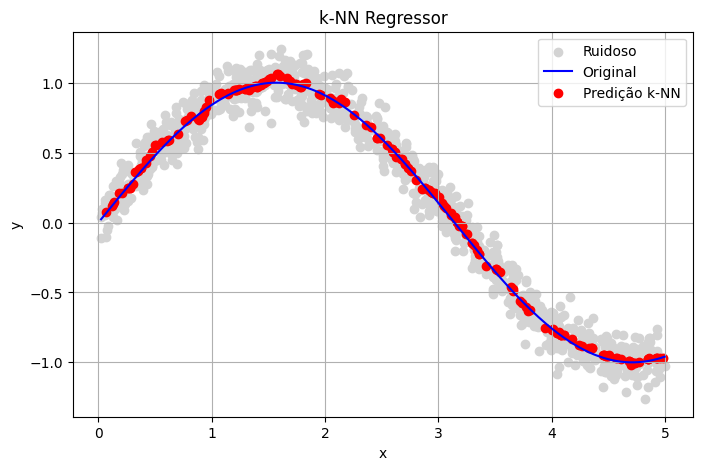

In [8]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error


# Dados
N = 1000
np.random.seed(42)
x = np.sort(5 * np.random.rand(N, 1), axis=0)
y = np.sin(x).ravel()
y_noise = y + 0.1 * np.random.randn(N)

# Dividir
x_train, x_test, y_train, y_test = train_test_split(x, y_noise, test_size=0.2, random_state=42)

# GridSearch
param_grid = {
    'n_neighbors': [1,2,3,4,5,6,7,8,9,10,15,20],
    'weights': ['uniform', 'distance']
}
grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, verbose=2, n_jobs=-1)
grid.fit(x_train, y_train)
print("Melhores parâmetros:", grid.best_params_)

# Predição
y_pred = grid.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse:.4f}')

plt.figure(figsize=(8,5))
plt.scatter(x, y_noise, color='lightgray', label='Ruidoso')
plt.plot(x, y, color='blue', label='Original')
plt.scatter(x_test, y_pred, color='red', label='Predição k-NN')
plt.title('k-NN Regressor')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()


# Exercício 5 - Detecção BPSK com k-NN

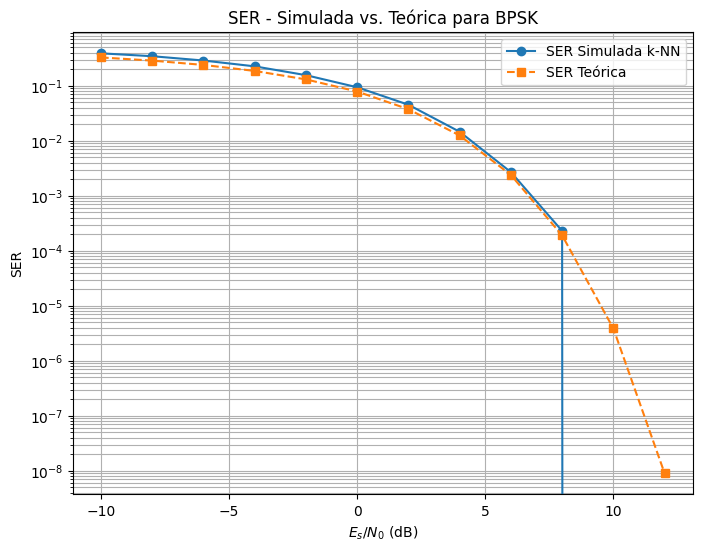

In [5]:

from scipy.special import erfc

# SER teórica
def ser_theoretical(esn0_linear):
    return 0.5 * erfc(np.sqrt(esn0_linear))

N = 1000000
esn0_dB = np.array([-10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12])
esn0_linear = 10**(esn0_dB/10)

bits = np.random.randint(0, 2, N)
symbols = 2*bits - 1

ser_simulated = []

for esn0 in esn0_linear:
    noise_std = np.sqrt(1/(2*esn0))
    noise = noise_std * np.random.randn(N)
    received = symbols + noise

    X = received.reshape(-1,1)
    y = bits

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    errors = np.sum(y_pred != y_test)
    ser = errors / len(y_test)
    ser_simulated.append(ser)

ser_theory = ser_theoretical(esn0_linear)

plt.figure(figsize=(8,6))
plt.semilogy(esn0_dB, ser_simulated, 'o-', label='SER Simulada k-NN')
plt.semilogy(esn0_dB, ser_theory, 's--', label='SER Teórica')
plt.xlabel('$E_s/N_0$ (dB)')
plt.ylabel('SER')
plt.title('SER - Simulada vs. Teórica para BPSK')
plt.grid(True, which='both')
plt.legend()
plt.show()
